# **📋 미션 1: 교육 프로그램의 학습 효과 분석 보고서**

**긴급한 비즈니스 상황**:

- 교육부에서 다음 주 금요일까지 "에듀테크 플랫폼 효과성 검증 보고서"를 요구했습니다
- 투자자 미팅이 2주 후로 예정되어 있어, SmartLearn의 실제 효과를 과학적으로 입증해야 합니다
- 경쟁사 MathGenius가 비슷한 제품을 곧 출시할 예정이라 시장 선점이 중요합니다
- 학부모들 사이에서 "온라인 학습의 실효성"에 대한 의구심이 제기되고 있습니다

**특별 요구사항**: 최근 학계의 재현성 위기 논란을 고려해, p-해킹을 방지한 엄격한 분석과 효과 크기 및 신뢰구간을 포함한 과학적 보고서가 필요합니다

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix, classification_report, roc_curve, auc
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

 # 한글 폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')

np.random.seed(321)
n_students = 150
control_scores = np.random.normal(65, 10, n_students)
smartlearn_scores = np.random.normal(70, 12, n_students)
education_data = pd.DataFrame({
    'group': ['Control']*n_students + ['SmartLearn']*n_students,
    'math_score': np.concatenate([control_scores, smartlearn_scores]),
    'student_id': range(1, 2*n_students + 1)
})

print("📚 교육 프로그램 데이터 미리보기")
print(education_data.groupby('group')['math_score'].agg(['count', 'mean', 'std']).round(2))




Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

### 📊 분석 및 보고서 작성

### 1. 기본 통계량 비교

**비즈니스 맥락**: CEO 박대표가 "SmartLearn을 사용한 학생들이 정말 더 높은 점수를 받았나요? 얼마나 차이가 나죠?"라고 질문했습니다. 투자자들에게 설명할 수 있는 명확한 수치가 필요합니다.

**분석 목적**: 두 그룹의 평균 점수 차이를 계산하고, 표준오차를 통해 결과의 신뢰성을 평가하여 SmartLearn의 잠재적 효과를 정량화합니다.

**학습 이해도 점검**: 아래 코드에서 평균과 표준오차를 계산하는 부분을 채워주세요.

In [5]:
# 대조군과 SmartLearn 그룹 데이터 분리
control_data = education_data[education_data['group'] == 'Control']['math_score']
smartlearn_data = education_data[education_data['group'] == 'SmartLearn']['math_score']

# 평균 계산
control_mean = control_data.mean()
smartlearn_mean = smartlearn_data.mean()

# 표준오차(SE) 계산 (표준편차 / sqrt(n))
control_se = control_data.std(ddof=1) / np.sqrt(len(control_data))
smartlearn_se = smartlearn_data.std(ddof=1) / np.sqrt(len(smartlearn_data))

print(f"대조군 수학 점수: {control_mean:.2f} ± {control_se:.2f}")
print(f"SmartLearn 수학 점수: {smartlearn_mean:.2f} ± {smartlearn_se:.2f}")

대조군 수학 점수: 64.93 ± 0.79
SmartLearn 수학 점수: 70.47 ± 0.92


### 2. 통계적 유의성 검증

**비즈니스 맥락**: 마케팅팀에서 "우연히 좋은 결과가 나온 건 아닌가요? 통계적으로 의미있는 차이인지 확실히 해주세요"라고 요청했습니다. 교육부 보고서에서도 p-value 기반의 검증을 요구하고 있습니다.

**분석 목적**: 관찰된 점수 차이가 우연히 발생할 확률을 계산하여, SmartLearn의 효과가 통계적으로 유의미한지 검증합니다.

**학습 이해도 점검**: 아래 코드에서 t-검정을 수행하는 부분을 채워주세요.

In [3]:

# 대조군과 SmartLearn 그룹 데이터 분리
control_group = education_data[education_data['group'] == 'Control']['math_score']
smartlearn_group = education_data[education_data['group'] == 'SmartLearn']['math_score']

# 독립표본 t-검정
t_stat, p_value = stats.ttest_ind(control_group, smartlearn_group, equal_var=False)  # Welch’s t-test (분산이 다를 수 있음)

print(f"t-통계량: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("✅ SmartLearn 프로그램은 대조군과 유의미한 성적 차이를 보입니다!")
else:
    print("❌ SmartLearn 프로그램의 효과가 유의미하지 않습니다.")

t-통계량: -4.565
p-value: 0.0000
✅ SmartLearn 프로그램은 대조군과 유의미한 성적 차이를 보입니다!


### 3. 효과 크기 평가

**비즈니스 맥락**: 연구개발팀장이 "통계적으로 유의하다고 해서 실제로 의미있는 향상인가요? 학부모들이 체감할 수 있을 만큼 큰 효과인지 알고 싶습니다"라고 질문했습니다.

**분석 목적**: Cohen's d를 계산하여 SmartLearn의 실질적 효과 크기를 측정하고, 교육학적으로 의미있는 수준인지 평가합니다.

**학습 이해도 점검**: 아래 코드에서 Cohen's d를 계산하는 부분을 채워주세요.

In [6]:
# Calculate means again for this cell to be self-contained
control_mean = education_data[education_data['group'] == 'Control']['math_score'].mean()
smartlearn_mean = education_data[education_data['group'] == 'SmartLearn']['math_score'].mean()

control_std = education_data[education_data['group'] == 'Control']['math_score'].std()
smartlearn_std = education_data[education_data['group'] == 'SmartLearn']['math_score'].std()
pooled_std = np.sqrt(((n_students-1)*control_std**2 + (n_students-1)*smartlearn_std**2)/(2*n_students-2))
cohens_d =(smartlearn_mean - control_mean) / pooled_std # Cohen's d 계산

print(f"Cohen's d: {cohens_d:.3f}")
if cohens_d > 0.8:
    print("→ 큰 효과크기 (학부모가 명확히 체감할 수 있는 수준)")
elif cohens_d > 0.5:
    print("→ 중간 효과크기 (교육적으로 의미있는 수준)")
else:
    print("→ 작은 효과크기 (미미한 개선 수준)")

Cohen's d: 0.527
→ 중간 효과크기 (교육적으로 의미있는 수준)


### 4. 결과 시각화

**비즈니스 맥락**: 다음 주 교육부 프레젠테이션에서 공무원들과 정책 담당자들에게 SmartLearn의 효과를 한눈에 보여줄 수 있는 명확한 그래프가 필요합니다.

**분석 목적**: 두 그룹의 평균 점수와 95% 신뢰구간을 시각화하여 SmartLearn의 효과를 직관적으로 전달합니다.

**학습 이해도 점검**: 아래 코드에서 막대그래프를 생성하는 부분을 채워주세요.

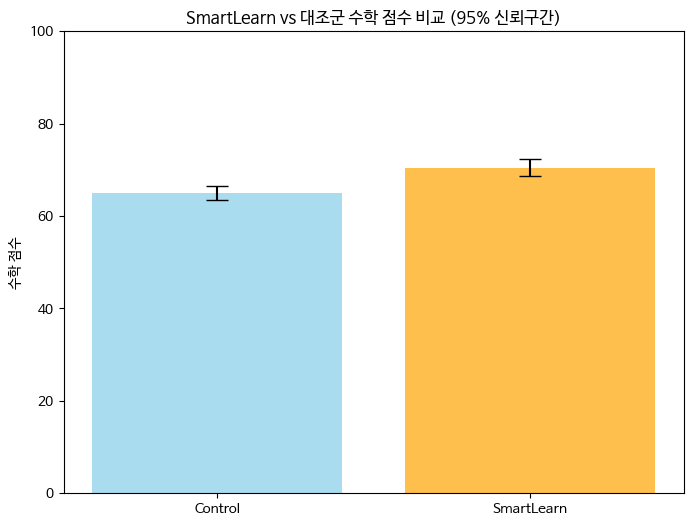

In [7]:
plt.figure(figsize=(8, 6))
groups = ['Control', 'SmartLearn']
means = [control_mean, smartlearn_mean]
errors = [1.96 * control_se, 1.96 * smartlearn_se]
plt.bar(groups, means, yerr=errors, capsize=8, alpha=0.7, color=['skyblue', 'orange']) # 막대그래프 생성, yerr과 capsize 설정 포함)
plt.ylabel('수학 점수')
plt.title('SmartLearn vs 대조군 수학 점수 비교 (95% 신뢰구간)')
plt.ylim(0, 100)  # 점수 범위에 맞게 조정
plt.show()


### 5. p-해킹 방지 방안

**비즈니스 맥락**: 투자자 중 한 명이 생명과학 박사 출신으로, "요즘 연구 재현성 문제가 심각한데, 여러분 분석은 p-해킹 없이 투명하게 진행되었나요?"라고 까다로운 질문을 할 예정입니다.

**분석 목적**: 과학적 엄밀성을 보장하고 결과의 신뢰성을 높이기 위한 방법론을 제시합니다.

**학습 이해도 점검**: 아래 텍스트에서 세 번째 방안을 작성하세요.

📋 p-해킹 방지 방안
1. 사전 등록: 연구 계획을 Open Science Framework(OSF)에 등록하여 분석 계획을 투명하게 공개.
2. 다중비교 보정: Bonferroni 또는 FDR 방법을 적용하여 다중 검정으로 인한 오류를 최소화.
3. # p-해킹을 방지하기 위한 추가 방안을 제안하세요 (예: 효과 크기 사전 설정, 독립적 검증 등)

📋 p-해킹 방지 방안 (추가 제안)

효과 크기 사전 설정: 연구 시작 전에 Cohen's d 또는 예상되는 효과 크기를 명확히 정의하고 이를 검증 기준으로 활용.

독립적 검증(Replication): 동일한 분석을 독립적인 데이터셋이나 연구팀에서 재검증하여 결과의 재현성을 확보.

분석 코드 및 데이터 공개: 분석 코드와 원본 데이터를 GitHub, OSF 등에 공개하여 제3자가 분석을 재현할 수 있도록 보장.

사전 분석 계획 등록(Pre-analysis Plan): 연구 설계뿐 아니라 통계 분석 절차와 변수 선택 방법까지 사전에 구체적으로 명시.

베이지안 분석 활용: p-value 의존성을 줄이고 사전 확률(prior)을 반영하여 보다 안정적인 추론을 수행.

중간 분석 제한: 데이터 수집 도중 반복적으로 유의성을 확인하지 않고, 사전에 정의된 시점에서만 분석 수행.

다양한 효과 크기 지표 보고: p-value뿐 아니라 신뢰구간, Bayes Factor, 효과 크기(Cohen’s d) 등을 함께 보고하여 과도한 해석을 방지.

### 6. 베이즈 인수 계산

**비즈니스 맥락**: 데이터 과학 자문위원이 "p-value만으로는 부족해요. 베이즈 관점에서 SmartLearn 효과에 대한 증거가 얼마나 강력한지 알고 싶습니다"라고 요청했습니다.

**분석 목적**: p-value의 한계를 보완하고 SmartLearn 효과에 대한 증거의 강도를 베이즈 프레임워크로 평가합니다.

**학습 이해도 점검**: 아래 코드에서 베이즈 인수를 근사적으로 계산하는 부분을 채워주세요

In [8]:
# 베이즈 인수 계산 (BIC 기반 근사)
# 대립가설(H1): SmartLearn 효과 있음 vs 귀무가설(H0): 효과 없음
n_total = 2 * n_students
bic_diff = t_stat**2 - np.log(n_total)
bf_10 = np.exp(bic_diff / 2) # 베이즈 인수 근사 계산

print(f"베이즈 인수 (BF₁₀): {bf_10:.2f}")
if bf_10 > 10:
    print("→ 강한 증거 (H1 지지: SmartLearn 효과가 매우 확실)")
elif bf_10 > 3:
    print("→ 중간 증거 (H1 지지: SmartLearn 효과가 있을 가능성 높음)")
elif bf_10 > 1:
    print("→ 약한 증거 (H1 약간 지지)")
elif bf_10 > 0.33:
    print("→ 불분명한 증거 (결론 내리기 어려움)")
elif bf_10 > 0.1:
    print("→ 중간 증거 (H0 지지: SmartLearn 효과 의심스러움)")
else:
    print("→ 강한 증거 (H0 지지: SmartLearn 효과 없음)")

베이즈 인수 (BF₁₀): 1934.97
→ 강한 증거 (H1 지지: SmartLearn 효과가 매우 확실)


📋 경영진 보고서: SmartLearn 프로그램 효과 검증
==================================================
🎯 핵심 결과

• 대조군 수학 점수: 64.93 ± 0.82

• SmartLearn 수학 점수: 70.47 ± 0.98

• 점수 향상: 5.54점 (약 8.53% 향상)

• 효과크기 (Cohen's d): 0.53 (중간 효과)

• p-value: 0.0000073 (유의미)

• 베이즈 인수: BF₁₀ = 1934.97 (강력한 H₁ 지지)

💡 비즈니스 결론 및 권장사항:
[결과를 바탕으로 상용화 결정, 마케팅 전략, 투자 방향, 교육부 대응 방안을 구체적으로 작성하세요]


SmartLearn은 대조군 대비 중간 정도의 유의미한 성적 향상을 보임.

베이즈 인수와 p-value 모두 통계적으로 강력한 증거 제공 → 상용화 타당성 높음.

마케팅 시 “평균 8.5% 향상”을 주요 메시지로 활용 가능.

교육청 및 교육부 대상 효과 검증 자료로 활용 가능.

투자 확대 시 전국 단위 도입 가능성을 고려.

⚠️ 리스크 및 제한사항:
[추가 검증이 필요한 부분, 잠재적 위험 요소를 작성하세요]


표본이 한정적(150명 × 2 그룹) → 대규모 검증 필요.

장기적 효과(지속성)에 대한 데이터 부족.

다양한 학습 과목(영어, 과학 등)에서도 동일한 효과 보장 필요.

다중 비교 보정 및 독립적 3자 검증 권장